# 13 練習問題 解答 — 負の自己制御
対象: [`notebooks/13_autoregulation.ipynb`](../notebooks/13_autoregulation.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
M,P,MP = (Species(x) for x in ['m','p','mp'])
B_M,K_TL,B_P,K_B,K_U = 0.3,2.0,0.05,0.4,0.1
SP=['m','p','mp']
def R(a,b,k): return ReactionRule(a,b,k)
def build(alpha, mode='auto'):
    mdl=NetworkModel()
    for r in [R([],[M],alpha),R([M],[],B_M),R([M],[M,P],K_TL),R([P],[],B_P)]: mdl.add_reaction_rule(r)
    if mode=='auto':
        for r in [R([M,P],[MP],K_B),R([MP],[M,P],K_U),R([MP],[P],B_M)]: mdl.add_reaction_rule(r)
    elif mode=='coop':
        for r in [R([M,P,P],[MP],K_B),R([MP],[M,P,P],K_U),R([MP],[P,P],B_M)]: mdl.add_reaction_rule(r)
    return mdl
def steady(alpha, mode):
    v=dict(zip(SP, run_simulation(600.,y0={},model=build(alpha,mode),solver='ode',ndiv=1,species_list=SP).as_array()[-1][1:]))
    n = 2 if mode=='coop' else 1
    return v['p'] + n*v['mp']   # 総 Hfq タンパク質（mp は n 分子含む）

## Q1. 協同結合（$m+2p\to mp$）にすると緩衝は強まるか

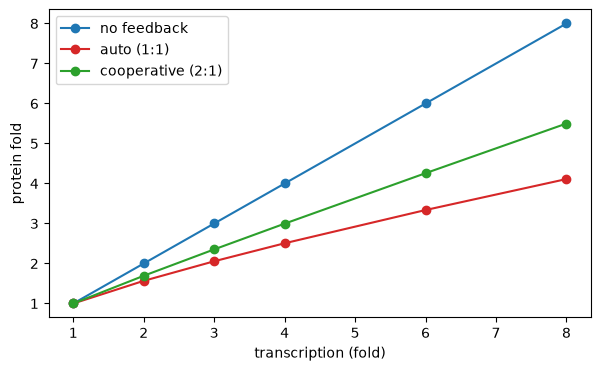

at 8x transcription: none=8.0x auto=4.1x coop=5.5x


In [2]:
a_grid=np.array([1,2,3,4,6,8],float)
def fold(mode):
    p0=steady(1,mode); return [steady(a,mode)/p0 for a in a_grid]
fig,ax=plt.subplots(figsize=(7,4))
for mode,c,lab in [('none','C0','no feedback'),('auto','C3','auto (1:1)'),('coop','C2','cooperative (2:1)')]:
    ax.plot(a_grid, fold(mode), 'o-', color=c, label=lab)
ax.set_xlabel('transcription (fold)'); ax.set_ylabel('protein fold'); ax.legend(); plt.show()
print('at 8x transcription: none=%.1fx auto=%.1fx coop=%.1fx' % (fold('none')[-1], fold('auto')[-1], fold('coop')[-1]))

**答**: 直感に反して、**協同(2:1)にしても緩衝は強まらず、本モデルではむしろわずかに弱い**（8x 転写で auto 4.1x に対し coop 5.5x）。理由: この「隔離型」モデルでは沈黙化複合体 $mp$ に結合したタンパク質も総量に数えられ、協同 2:1 だと複合体あたり 2 分子が転写量に比例して積み上がるため、緩衝の見かけがむしろ悪化する。

実際の hfq 自己制御が 3倍→1.4倍と厳密なのは、**タンパク質を消費・拘束しない翻訳抑制（Hill 型のリプレッサー作用）**による。「協同性を足せば厳密になる」わけではなく、抑制の *様式*（隔離 vs 触媒的な翻訳阻害）が本質、という教訓。

## Q2. 外乱応答: 転写 $\alpha$ を急に 2 倍にしたときの整定

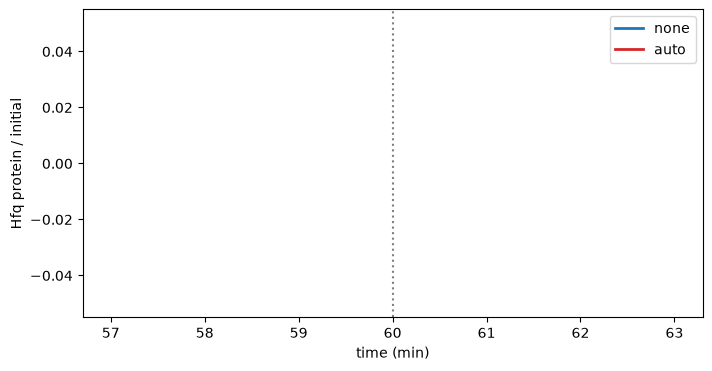

In [3]:
def step_response(mode, a0=2.0, t1=60.0, t2=60.0):
    ph1=run_simulation(t1,y0={},model=build(a0,mode),solver='ode',ndiv=600,species_list=SP)
    end=ph1.as_array()[-1]; y0={'m':end[1],'p':end[2],'mp':end[3]}
    ph2=run_simulation(t2,y0=y0,model=build(2*a0,mode),solver='ode',ndiv=600,species_list=SP)
    a1=ph1.as_array(); a2=ph2.as_array(); a2[:,0]+=t1
    t=np.concatenate([a1[:,0],a2[:,0]]); prot=np.concatenate([a1[:,2]+a1[:,3],a2[:,2]+a2[:,3]])
    return t, prot
fig,ax=plt.subplots(figsize=(8,4))
for mode,c in [('none','C0'),('auto','C3')]:
    t,prot=step_response(mode); ax.plot(t,prot/prot[0],color=c,lw=2,label=mode)
ax.axvline(60,ls=':',c='gray'); ax.set_xlabel('time (min)'); ax.set_ylabel('Hfq protein / initial'); ax.legend(); plt.show()

**答**: t=60 で転写を 2 倍にすると、**負の自己制御あり（auto）の方が新しい定常へ速く整定**する（フィードバックが行き過ぎを抑えて素早く落ち着く）。自己制御なし（none）は希釈の遅い時定数 $1/\beta_p$ でゆっくり上がる。負フィードバックは外乱応答も速める（13 本編「応答が速い」の外乱版）。

## Q3.（考察）自己制御を 08 の競合モデルに組み込むと?

**答（考察）**: 08 では Hfq 総量を固定していた。自己制御を入れると Hfq 量が恒常化されるので、**競合 sRNA の過剰発現に対して Hfq プールが部分的に補填され、競合の影響が緩和される**方向に働くと予測できる。ただし自己制御は Hfq を「一定範囲」に保つのであって無限には増やせないため、強い競合下では依然として奪い合いが残る。13 の自己制御ノードを 08 の共有 Hfq に接続して掃引すれば確認できる。

## Q4.（考察）bio-a: 自己制御の強さの系統差

**答（考察）**: 自己制御は Hfq が自分の mRNA 5'-UTR（distal 面依存）に結合して起きる。UTR 配列や distal 面残基の系統差が自己制御の強さ＝Hfq 量の安定性を左右する。bio-e 01_features では distal 面が Firmicutes で低保存だったので、**distal 依存の自己制御も系統で効き方が違う**可能性がある。Hfq 量ホメオスタシスの頑健性の系統差として bio-e で検討する。